In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing,ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('Air_Passengers.csv',index_col='Month',parse_dates=True)
df.head(),df.tail(),df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


(            #Passengers
 Month                  
 1949-01-01          112
 1949-02-01          118
 1949-03-01          132
 1949-04-01          129
 1949-05-01          121,
             #Passengers
 Month                  
 1960-08-01          606
 1960-09-01          508
 1960-10-01          461
 1960-11-01          390
 1960-12-01          432,
 None)

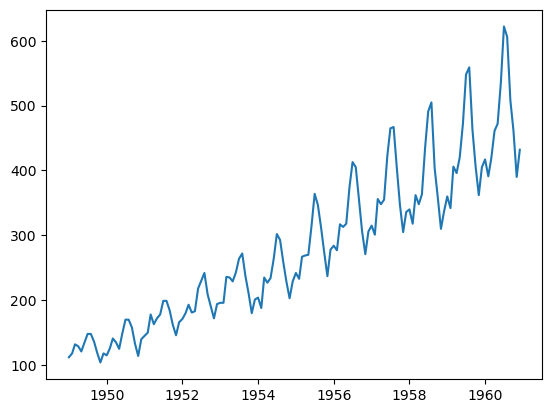

In [4]:
plt.plot(df)

<Axes: xlabel='Month'>

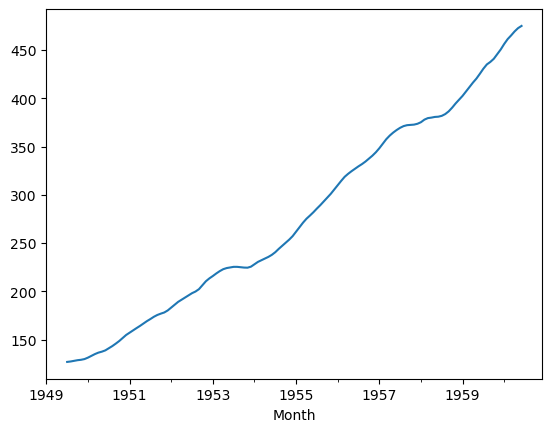

In [6]:
model=seasonal_decompose(df['#Passengers'],model='mul')
model.trend.plot()

<Axes: xlabel='Month'>

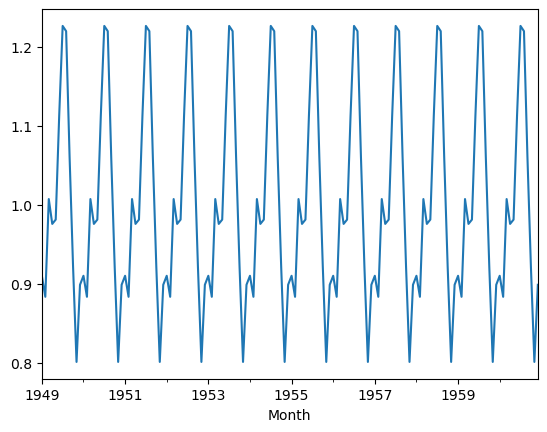

In [7]:
model.seasonal.plot()

<Axes: xlabel='Month'>

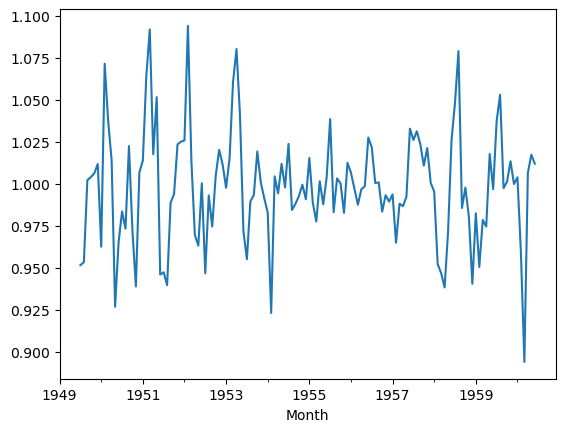

In [9]:
model.resid.plot()

# simple exponential smoothing

In [10]:
simple=SimpleExpSmoothing(df['#Passengers']).fit(smoothing_level=0.5)

In [11]:
simple_pred=simple.fittedvalues
simple_pred

Month
1949-01-01    112.000000
1949-02-01    112.000000
1949-03-01    115.000000
1949-04-01    123.500000
1949-05-01    126.250000
                 ...    
1960-08-01    558.192821
1960-09-01    582.096411
1960-10-01    545.048205
1960-11-01    503.024103
1960-12-01    446.512051
Length: 144, dtype: float64

In [13]:
simple_forc=simple.forecast(20)
simple_forc

1961-01-01    439.256026
1961-02-01    439.256026
1961-03-01    439.256026
1961-04-01    439.256026
1961-05-01    439.256026
1961-06-01    439.256026
1961-07-01    439.256026
1961-08-01    439.256026
1961-09-01    439.256026
1961-10-01    439.256026
1961-11-01    439.256026
1961-12-01    439.256026
1962-01-01    439.256026
1962-02-01    439.256026
1962-03-01    439.256026
1962-04-01    439.256026
1962-05-01    439.256026
1962-06-01    439.256026
1962-07-01    439.256026
1962-08-01    439.256026
Freq: MS, dtype: float64

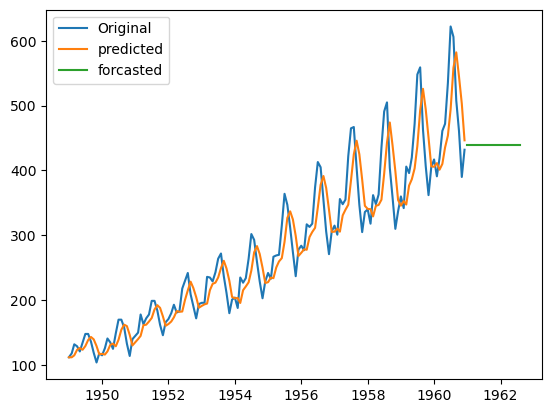

In [14]:
plt.plot(df['#Passengers'],label='Original')
plt.plot(simple_pred,label='predicted')
plt.plot(simple_forc,label='forcasted')
plt.legend()

# Double exponential smoothing

In [15]:
double=ExponentialSmoothing(df['#Passengers'],trend='mul').fit(smoothing_level=0.5,smoothing_trend=0.6)

In [16]:
double_pred=double.fittedvalues
double_pred

Month
1949-01-01    114.230412
1949-02-01    118.852953
1949-03-01    124.165736
1949-04-01    136.832020
1949-05-01    139.557040
                 ...    
1960-08-01    668.882813
1960-09-01    697.957404
1960-10-01    606.316698
1960-11-01    498.029410
1960-12-01    387.405890
Length: 144, dtype: float64

In [17]:
double_forc=double.forecast(20)
double_forc

1961-01-01    369.813057
1961-02-01    333.806967
1961-03-01    301.306535
1961-04-01    271.970442
1961-05-01    245.490597
1961-06-01    221.588908
1961-07-01    200.014358
1961-08-01    180.540370
1961-09-01    162.962427
1961-10-01    147.095924
1961-11-01    132.774231
1961-12-01    119.846940
1962-01-01    108.178288
1962-02-01     97.645731
1962-03-01     88.138654
1962-04-01     79.557215
1962-05-01     71.811289
1962-06-01     64.819530
1962-07-01     58.508510
1962-08-01     52.811948
Freq: MS, dtype: float64

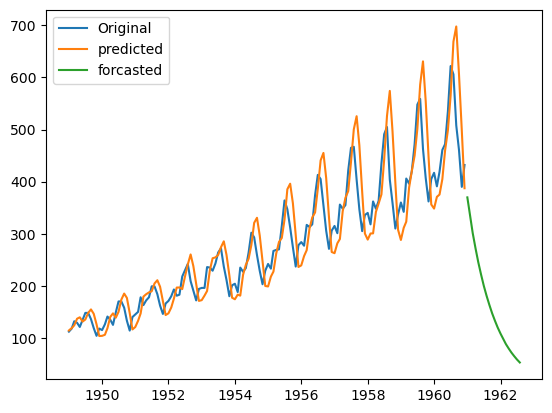

In [18]:
plt.plot(df['#Passengers'],label='Original')
plt.plot(double_pred,label='predicted')
plt.plot(double_forc,label='forcasted')
plt.legend()
# tripple

In [19]:
tripple=ExponentialSmoothing(df['#Passengers'],trend='mul',seasonal='mul').fit(smoothing_level=0.5,smoothing_trend=0.6,smoothing_seasonal=0.7)

In [21]:
tripple_pred=tripple.fittedvalues
tripple_pred

Month
1949-01-01    111.898288
1949-02-01    117.588756
1949-03-01    131.369386
1949-04-01    127.904383
1949-05-01    123.944726
                 ...    
1960-08-01    634.722978
1960-09-01    501.230798
1960-10-01    437.942507
1960-11-01    404.237154
1960-12-01    437.766377
Length: 144, dtype: float64

In [22]:
tripple_forc=tripple.forecast(20)
tripple_forc

1961-01-01    442.655567
1961-02-01    417.243246
1961-03-01    462.558620
1961-04-01    517.014102
1961-05-01    511.840927
1961-06-01    570.879711
1961-07-01    657.250997
1961-08-01    645.486082
1961-09-01    546.481149
1961-10-01    487.681865
1961-11-01    406.610919
1961-12-01    457.744226
1962-01-01    465.925185
1962-02-01    439.176984
1962-03-01    486.874505
1962-04-01    544.192616
1962-05-01    538.747497
1962-06-01    600.889844
1962-07-01    691.801516
1962-08-01    679.418140
Freq: MS, dtype: float64

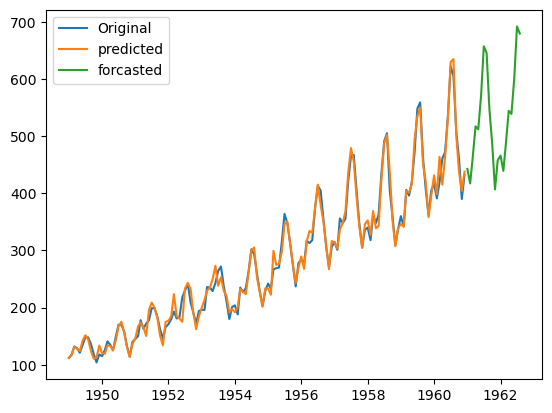

In [23]:
plt.plot(df['#Passengers'],label='Original')
plt.plot(tripple_pred,label='predicted')
plt.plot(tripple_forc,label='forcasted')
plt.legend()